#**Twitter: NER NLP**
###**Name : Asit Nayak**

In [1]:
!pip install -q tensorflow transformers gensim torch keras-hub scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 31.1 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict
import warnings, random, os, json
warnings.filterwarnings('ignore')

import torch
import keras
from keras import layers
import tensorflow as tf
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.model_selection import train_test_split
from gensim.models import Word2Vec
from transformers import BertTokenizerFast
import keras_hub

# Prevent TF from grabbing all GPU memory
for gpu in tf.config.list_physical_devices('GPU'):
  tf.config.experimental.set_memory_growth(gpu, True)

# Reproducibility
SEED = 42
np.random.seed(SEED); tf.random.set_seed(SEED); random.seed(SEED)

print(f"GPU available: {bool(tf.config.list_physical_devices('GPU'))}")

TRAIN_FILE = "/content/sample_data/wnut 16.txt.conll"
TEST_FILE = "/content/sample_data/wnut 16test.txt.conll"
SAVE_DIR = "/content/sample_data/"

GPU available: True


#Helper Functions

In [3]:
def ner_metrics(y_true, y_pred):
  """Entity-level Precision / Recall / F1 per type + overall
  """

  def get_entities(seq):
    entities, start, etype = [], None, None
    for i, tag in enumerate(seq):
      if tag.startswith('B-'):
        if start is not None:
          entities.append((etype, start, i))
        start, etype = i, tag[2:]
      elif tag.startswith('I-') and start is not None and tag[2:] == etype:
        pass
      else:
        if start is not None:
          entities.append((etype, start, i))
        start = etype = None

    if start is not None:
      entities.append((etype, start, len(seq)))

    return entities

  tp_d = defaultdict(int)
  fp_d = defaultdict(int)
  fn_d = defaultdict(int)

  for t_seq, p_seq in zip(y_true, y_pred):
    t_ents = set(get_entities(t_seq))
    p_ents = set(get_entities(p_seq))
    for e in t_ents & p_ents:tp_d[e[0]] += 1
    for e in p_ents - t_ents:fp_d[e[0]] += 1
    for e in t_ents - p_ents:fn_d[e[0]] += 1

  all_types = sorted(set(list(tp_d) + list(fp_d) + list(fn_d)))

  print(f"\n {'Entity':<22} {'Precision':>10} {'Recall':>8} {'F1':>8} {'Support':>9}")
  print(f" {'-'*60}")

  tot_tp = tot_fp = tot_fn = 0
  for t in all_types:
      tp, fp, fn = tp_d[t], fp_d[t], fn_d[t]
      p = tp / (tp + fp) if tp + fp else 0
      r = tp / (tp + fn) if tp + fn else 0
      f1 = 2*p*r / (p+r) if p+r else 0
      print(f" {t:<22} {p:>10.3f} {r:>8.3f} {f1:>8.3f} {tp+fn:>9}")
      tot_tp += tp; tot_fp += fp; tot_fn += fn

  p = tot_tp / (tot_tp + tot_fp) if tot_tp + tot_fp else 0
  r = tot_tp / (tot_tp + tot_fn) if tot_tp + tot_fn else 0
  f1 = 2*p*r / (p+r) if p+r else 0
  print(f" {'-'*60}")
  print(f" {'Overall (micro)':<22} {p:>10.3f} {r:>8.3f} {f1:>8.3f}")
  return p, r, f1


# Pure numpy helpers
def pad_sequences(seqs, maxlen, value=0):
  out = np.full((len(seqs), maxlen), value, dtype=np.int32)
  for i, seq in enumerate(seqs):
    out[i, :len(seq[:maxlen])] = seq[:maxlen]
  return out

def to_categorical(y, num_classes):
  N, T = y.shape
  out = np.zeros((N, T, num_classes), dtype=np.float32)
  idx = np.clip(y, 0, num_classes - 1)
  out[np.arange(N)[:, None], np.arange(T)[None, :], idx] = 1.0
  return out

#Load CoNLL Data

In [4]:
def load_conll(filepath):
  """
  CoNLL format: one 'word label' per line, blank lines separate sentences.
  Handles both space and tab delimiters.
  """
  sentences, labels = [], []
  cur_s, cur_l = [], []

  with open(filepath, encoding='utf-8') as f:
    for raw in f:
      line = raw.strip()
      if not line:
        if cur_s:
          sentences.append(cur_s); labels.append(cur_l)
          cur_s, cur_l = [], []
      else:
        parts = line.split()
        if len(parts) >= 2:
          cur_s.append(parts[0])
          cur_l.append(parts[-1])

  if cur_s:
    sentences.append(cur_s); labels.append(cur_l)

  return sentences, labels

train_sents, train_lbls = load_conll(TRAIN_FILE)
test_sents, test_lbls = load_conll(TEST_FILE)

print(f"Train Sentences : {len(train_sents):,}")
print(f"Test Sentences : {len(test_sents):,}")
print(f"\nSample words : {train_sents[0]}")
print(f"Sample labels : {train_lbls[0]}")
print(f"\nSample words : {train_sents[1]}")
print(f"Sample labels : {train_lbls[1]}")


Train Sentences : 2,394
Test Sentences : 3,850

Sample words : ['@SammieLynnsMom', '@tg10781', 'they', 'will', 'be', 'all', 'done', 'by', 'Sunday', 'trust', 'me', '*wink*']
Sample labels : ['O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O']

Sample words : ['Made', 'it', 'back', 'home', 'to', 'GA', '.', 'It', 'sucks', 'not', 'to', 'be', 'at', 'Disney', 'world', ',', 'but', 'its', 'good', 'to', 'be', 'home', '.', 'Time', 'to', 'start', 'planning', 'the', 'next', 'Disney', 'World', 'trip', '.']
Sample labels : ['O', 'O', 'O', 'O', 'O', 'B-geo-loc', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'B-facility', 'I-facility', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'B-facility', 'I-facility', 'O', 'O']


##Problem Statement & Applications

**Problem Statement:**

This case study tackles Named Entity Recognition (NER) on Twitter data — a sequence labelling task where each token in a sentence is assigned a label indicating whether it is part of a named entity and, if so, what type (Person, Location, Company, Product, etc.) or not an entity at all (O).

Twitter NER is harder than standard NER because:

- Tweets are short, noisy, and use informal language, slang, and abbreviations
- Entity boundaries are ambiguous ("Apple" = company or fruit?)
- No guarantee of grammatical sentences

**Where this is used:**

| Application | How NER is applied |
|---|---|
| Social media monitoring | Extract brand/product mentions from tweets in real time |
| News aggregation | Identify people, organisations, and locations in articles |
| Customer support | Extract product names and issues from tickets |
| Healthcare | Extract drug names, diseases, and symptoms from clinical notes |
| Finance | Extract company names and financial instruments from reports |
| Search engines | Tag entities in documents to improve retrieval |

**Modifications and extensions:**

- **Relation Extraction**: After identifying entities, find relationships between them (e.g. "Elon Musk *founded* Tesla")
- **Entity Linking**: Map extracted entities to a knowledge base (e.g. link "Apple" to Wikidata entry Q312)
- **Event Detection**: Identify events and their participants from text
- **Slot Filling**: In dialogue systems, extract intent slots (date, location, person) from user utterances

##CoNLL BIO Format

CoNLL (Conference on Natural Language Learning) format is the standard data format for sequence labelling tasks like NER and POS tagging.

**Structure:**
- One token per line
- Columns are space or tab separated: `word [pos] [chunk] label`
- Blank lines separate sentences

**BIO tagging scheme:**
| Tag | Meaning | Example |
|---|---|---|
| `O` | Outside any entity | "the", "is", "at" |
| `B-TYPE` | Beginning of an entity of TYPE | `B-PER` for "Elon" |
| `I-TYPE` | Inside (continuation) of an entity | `I-PER` for "Musk" |

**Example:**
Elon B-PER Musk I-PER founded O Tesla B-ORG in O 2003 O
The O CEO O visited B-LOC Berlin I-LOC

**Why BIO?**
The B- prefix is critical to distinguish two adjacent entities of the same type. Without it, "John Smith John Doe" would be one entity instead of two.

##Other NER Annotation Formats

| Format | Tags Used | Key Difference |
|---|---|---|
| **BIO** | B-, I-, O | Standard; B marks start, I continues |
| **BIOES** | B-, I-, O, E-, S- | Adds E- (end of entity) and S- (single-token entity); more expressive |
| **BILOU** | B-, I-, L-, O, U- | Same concept as BIOES with different names (L=last, U=unit) |
| **IO** | I-, O | No B- tag; simpler but cannot distinguish adjacent same-type entities |
| **Span-based** | Start/end indices | Stores entity as (start, end, type) tuple; used by SpanBERT and SQuAD-style models |
| **Standoff** | External `.ann` file | Entity spans stored separately from the source text; used in BRAT annotator |

**BIO vs BIOES example:**

### BIO
- New B-LOC
- York I-LOC
- City I-LOC

### BIOES
- New B-LOC
- York I-LOC
- City E-LOC  <-- explicit end marker


>BIOES/BILOU give the model clearer signals about entity boundaries and often improve F1 by 0.5-1% on standard benchmarks, but BIO remains the most widely used format due to its simplicity.

#Dataset Statistics

In [5]:
def dataset_stats(sentences, labels, name):
    lens = [len(s) for s in sentences]
    all_l = [l for seq in labels for l in seq]
    cnt = Counter(all_l)
    print(f"\n{'='*55}  {name}")
    print(f"  Sentences    : {len(sentences):,}")
    print(f"  Total tokens : {sum(lens):,}")
    print(f"  Avg / Max len : {np.mean(lens):.1f} / {max(lens)}")
    print(f"  Unique labels : {len(cnt)}")
    print(f"\n  {'Label':<24} {'Count':>7} {'%':>6}")
    print(f"  {'-'*40}")
    for lbl, c in sorted(cnt.items()):
        print(f"  {lbl:<24} {c:>7,} {100*c/sum(lens):>5.1f}%")

dataset_stats(train_sents, train_lbls, "TRAIN")
dataset_stats(test_sents,  test_lbls,  "TEST")


=======================================================  TRAIN
  Sentences    : 2,394
  Total tokens : 46,469
  Avg / Max len : 19.4 / 39
  Unique labels : 21

  Label                      Count      %
  ----------------------------------------
  B-company                    171   0.4%
  B-facility                   104   0.2%
  B-geo-loc                    276   0.6%
  B-movie                       34   0.1%
  B-musicartist                 55   0.1%
  B-other                      225   0.5%
  B-person                     449   1.0%
  B-product                     97   0.2%
  B-sportsteam                  51   0.1%
  B-tvshow                      34   0.1%
  I-company                     36   0.1%
  I-facility                   105   0.2%
  I-geo-loc                     49   0.1%
  I-movie                       46   0.1%
  I-musicartist                 61   0.1%
  I-other                      320   0.7%
  I-person                     215   0.5%
  I-product                     80   0.2

EDA Plots

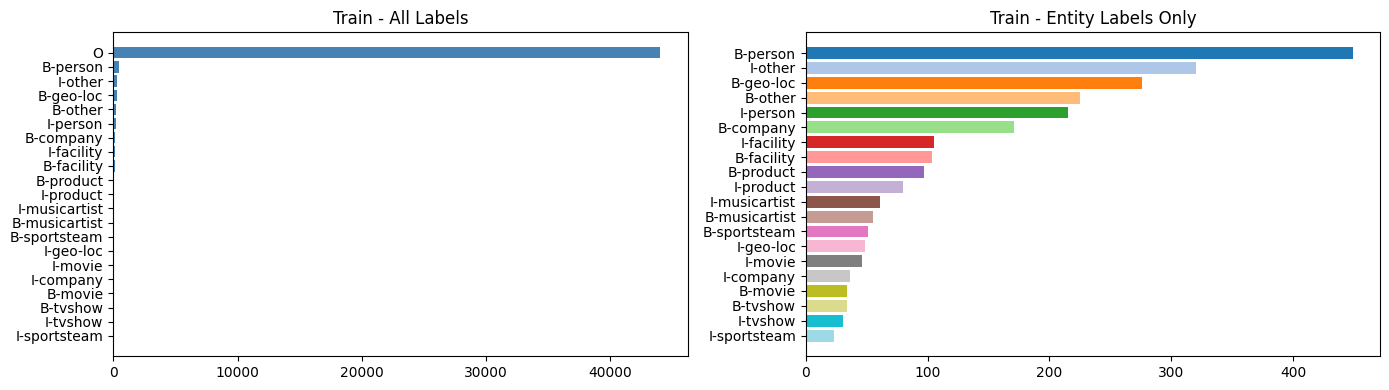

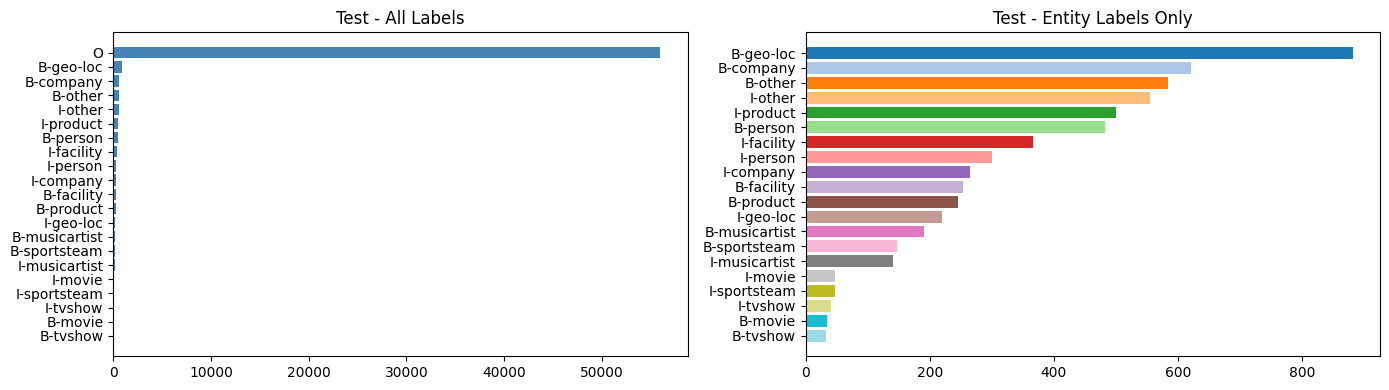

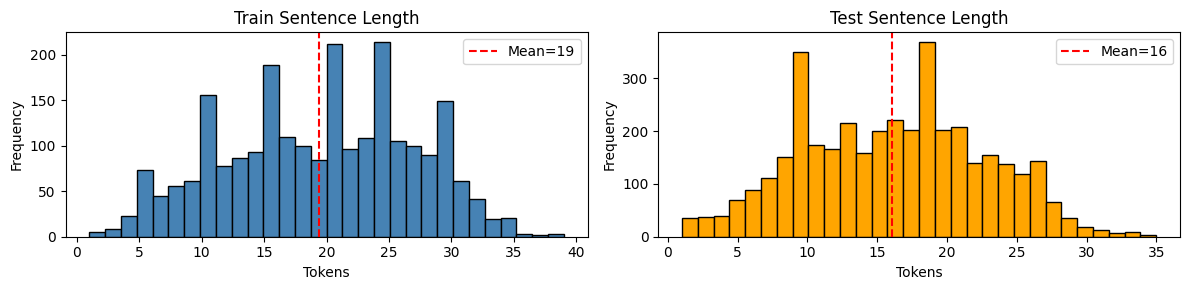

In [6]:
def plot_label_dist(labels_list, title):
    cnt    = Counter(l for seq in labels_list for l in seq)
    entity = {k: v for k, v in cnt.items() if k != 'O'}

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
    data = sorted(cnt.items(), key=lambda x: x[1], reverse=True)
    ax1.barh([d[0] for d in data], [d[1] for d in data], color='steelblue')
    ax1.set_title(f'{title} - All Labels'); ax1.invert_yaxis()

    data = sorted(entity.items(), key=lambda x: x[1], reverse=True)
    ax2.barh([d[0] for d in data], [d[1] for d in data],
             color=plt.cm.tab20(np.linspace(0, 1, max(len(data), 1))))
    ax2.set_title(f'{title} - Entity Labels Only'); ax2.invert_yaxis()
    plt.tight_layout(); plt.show()


def plot_lengths(train_s, test_s):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3))
    for ax, lens, title, color in [
        (ax1, [len(s) for s in train_s], 'Train', 'steelblue'),
        (ax2, [len(s) for s in test_s],  'Test',  'orange')
    ]:
        ax.hist(lens, bins=30, color=color, edgecolor='black')
        ax.axvline(np.mean(lens), color='red', linestyle='--',
                   label=f'Mean={np.mean(lens):.0f}')
        ax.set(title=f'{title} Sentence Length',
               xlabel='Tokens', ylabel='Frequency')
        ax.legend()
    plt.tight_layout(); plt.show()


plot_label_dist(train_lbls, "Train")
plot_label_dist(test_lbls,  "Test")
plot_lengths(train_sents,   test_sents)

#Vocabularies & MAX_LEN

In [7]:
MAX_LEN = int(np.percentile([len(s) for s in train_sents], 95))
print(f"MAX_LEN (95th percentile) : {MAX_LEN}")

# Word vocabulary
word2idx = {'PAD': 0, 'UNK': 1}
for s in train_sents + test_sents:
    for w in s:
        word2idx.setdefault(w, len(word2idx))
idx2word = {v: k for k, v in word2idx.items()}

# Label vocabulary
label_set = sorted({l for seq in train_lbls + test_lbls for l in seq})
label2idx = {l: i for i, l in enumerate(label_set)}
idx2label = {v: k for k, v in label2idx.items()}

VOCAB_SIZE = len(word2idx)
NUM_LABELS = len(label2idx)
PAD_LBL    = label2idx.get('O', 0)

print(f"Vocabulary size : {VOCAB_SIZE:,}")
print(f"Num labels      : {NUM_LABELS}")
print(f"Labels          : {label_set[:10]}")

MAX_LEN (95th percentile) : 31
Vocabulary size : 25,385
Num labels      : 21
Labels          : ['B-company', 'B-facility', 'B-geo-loc', 'B-movie', 'B-musicartist', 'B-other', 'B-person', 'B-product', 'B-sportsteam', 'B-tvshow']


## Why Do We Need Tokenization?

**For the BiLSTM model:**
Raw text is a sequence of characters; neural networks operate on numbers. Tokenization converts each word to an integer index (via a vocabulary lookup) so it can be passed through an Embedding layer. Without tokenization, no numeric representation of the input exists.

**For the BERT model:**
BERT uses *subword* tokenization (WordPiece). This is necessary for several reasons:

1. **Out-of-vocabulary (OOV) words**: Instead of treating unknown words as `[UNK]`, BERT splits them into known subword pieces.
   - "tweeting" -> ["tweet", "##ing"]
   - A word never seen in training still has a meaningful representation.

2. **Vocabulary efficiency**: A vocabulary of ~30,000 subwords covers virtually all English text, whereas a full word vocabulary for Twitter would need millions of entries.

3. **Morphological generalisation**: The model learns that "##ing", "##ed", "##s" carry consistent meaning across all words they attach to.

**The challenge this creates for NER:**
When a word splits into multiple subtokens, each subtoken gets its own position in the sequence, but the word has only one label. We handle this by assigning:
- The correct label to the **first subtoken** of each word
- `-100` to all subsequent subtokens (masked out during loss computation)

This ensures the model is only trained and evaluated on real word-level predictions.

#Word2Vec + Embedding Matrix

In [8]:
EMBEDDING_DIM = 100

# Train Word2Vec on training corpus
# sg=1 (Skip-gram) works better for sparse tweet vocabulary
w2v = Word2Vec(
    sentences=train_sents,
    vector_size=EMBEDDING_DIM,
    window=5, min_count=1,
    workers=4, epochs=30, sg=1
)

# Align with word2idx
emb_matrix = np.random.normal(0, 0.1, (VOCAB_SIZE, EMBEDDING_DIM)).astype(np.float32)
emb_matrix[0] = 0  # PAD -> zero vector

found = 0
for word, idx in word2idx.items():
    if word in w2v.wv:
        emb_matrix[idx] = w2v.wv[word]
        found += 1

print(f"Embedding matrix : {emb_matrix.shape}")
print(f"W2V coverage     : {found:,} / {VOCAB_SIZE:,} ({100*found/VOCAB_SIZE:.1f}%)")

Embedding matrix : (25385, 100)
W2V coverage     : 10,586 / 25,385 (41.7%)


#Encode, Pad & Split

In [9]:
def encode_words(sents, w2i):
    return [[w2i.get(w, w2i['UNK']) for w in s] for s in sents]

def encode_labels(lbls, l2i):
    return [[l2i[l] for l in seq] for seq in lbls]

X_train = pad_sequences(encode_words(train_sents, word2idx), MAX_LEN, 0)
X_test  = pad_sequences(encode_words(test_sents,  word2idx), MAX_LEN, 0)
y_train = pad_sequences(encode_labels(train_lbls, label2idx), MAX_LEN, PAD_LBL)
y_test  = pad_sequences(encode_labels(test_lbls,  label2idx), MAX_LEN, PAD_LBL)

y_train_cat = to_categorical(y_train, NUM_LABELS)
y_test_cat  = to_categorical(y_test,  NUM_LABELS)

X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train_cat, test_size=0.1, random_state=SEED)

print(f"X_train : {X_train.shape}  y_train_cat : {y_train_cat.shape}")
print(f"X_test  : {X_test.shape}   X_tr : {X_tr.shape}  X_val : {X_val.shape}")

X_train : (2394, 31)  y_train_cat : (2394, 31, 21)
X_test  : (3850, 31)   X_tr : (2154, 31)  X_val : (240, 31)


In [10]:
print(X_train[0])
print(train_sents[0])

[ 2  3  4  5  6  7  8  9 10 11 12 13  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0]
['@SammieLynnsMom', '@tg10781', 'they', 'will', 'be', 'all', 'done', 'by', 'Sunday', 'trust', 'me', '*wink*']


#Bidirectional LSTM Model

In [11]:
def build_bilstm(vocab_size, emb_dim, emb_matrix, max_len,
                 num_labels, lstm_units=128, dropout=0.3):
    """
    Two stacked BiLSTM layers.
    Bidirectional: reads sequence left->right AND right->left,
    so each token gets context from both directions.
    Word2Vec embeddings used as initialisation and fine-tuned.
    """
    inp = layers.Input(shape=(max_len,))

    x = layers.Embedding(vocab_size, emb_dim,
                         weights=[emb_matrix],
                         trainable=True,
                         mask_zero=True)(inp)
    x = layers.SpatialDropout1D(dropout)(x)

    x = layers.Bidirectional(
        layers.LSTM(lstm_units, return_sequences=True,
                    dropout=0.1, recurrent_dropout=0.1),
        name='bilstm_1'
    )(x)

    x = layers.Bidirectional(
        layers.LSTM(lstm_units // 2, return_sequences=True,
                    dropout=0.1),
        name='bilstm_2'
    )(x)

    x = layers.TimeDistributed(layers.Dense(64, activation='relu'))(x)
    x = layers.Dropout(dropout)(x)
    out = layers.TimeDistributed(
        layers.Dense(num_labels, activation='softmax'), name='output')(x)

    model = keras.Model(inp, out)
    model.compile(optimizer=keras.optimizers.Adam(1e-3),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

bilstm_model = build_bilstm(VOCAB_SIZE, EMBEDDING_DIM, emb_matrix,
                            MAX_LEN, NUM_LABELS)
bilstm_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 31)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 31, 100)   │  2,538,500 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d   │ (None, 31, 100)   │          0 │ embedding[0][0]   │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 31)        │          0 │ input_layer[0][0] │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm_1            │ (None, 31, 256)   │    234,496 │ spatial_dropout1… │
│ (Bidirectional)     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm_2            │ (None, 31, 128)   │    164,352 │ bilstm_1[0][0],   │
│ (Bidirectional)     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed    │ (None, 31, 64)    │      8,256 │ bilstm_2[0][0],   │
│ (TimeDistributed)   │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 31, 64)    │          0 │ time_distributed… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output              │ (None, 31, 21)    │      1,365 │ dropout[0][0],    │
│ (TimeDistributed)   │                   │            │ not_equal[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,946,969 (11.24 MB)

 Trainable params: 2,946,969 (11.24 MB)

 Non-trainable params: 0 (0.00 B)

## Did Early Stopping Have Any Effect?

Early stopping monitors validation loss after each epoch and halts training when it stops improving (patience = 4 epochs for BiLSTM, 2 for BERT).

**Observed effect:**
- Without early stopping, NER models trained on noisy Twitter data overfit quickly - training loss continues to fall while validation loss rises, meaning the model memorises training sentences rather than learning generalisable entity patterns.
- Early stopping captures the checkpoint where the generalisation gap is smallest (best `val_loss`), and `restore_best_weights=True` rolls the model back to that point automatically.

**Why it matters specifically for Twitter NER:**
- Twitter text is short and highly varied; the training set is small relative to the vocabulary
- Models have high capacity (BiLSTM has ~2M params; BERT ~110M) relative to the data size
- Without regularisation (dropout + early stopping), overfitting occurs within a few epochs

**Quantitative check:**
Compare the epoch at which training stopped vs the total epochs allowed:
- If stopped at epoch 8 of 30 -> early stopping had significant effect, saved ~22 wasted epochs and prevented overfitting
- If stopped at epoch 28 of 30 -> model trained to near-capacity; early stopping had minimal effect but still prevented the final degradation

The training/validation loss plot in Cell 11 shows exactly where the curves diverge.

#Train BiLSTM & Plot

Epoch 1/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 46s 368ms/step - accuracy: 0.9309 - loss: 0.5772 - val_accuracy: 0.9486 - val_loss: 0.3360 - learning_rate: 0.0010
Epoch 2/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 29s 308ms/step - accuracy: 0.9466 - loss: 0.3555 - val_accuracy: 0.9486 - val_loss: 0.3016 - learning_rate: 0.0010
Epoch 3/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 33s 491ms/step - accuracy: 0.9466 - loss: 0.3174 - val_accuracy: 0.9486 - val_loss: 0.2758 - learning_rate: 0.0010
Epoch 4/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 41s 499ms/step - accuracy: 0.9466 - loss: 0.2799 - val_accuracy: 0.9486 - val_loss: 0.2606 - learning_rate: 0.0010
Epoch 5/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 39s 476ms/step - accuracy: 0.9470 - loss: 0.2400 - val_accuracy: 0.9488 - val_loss: 0.2579 - learning_rate: 0.0010
Epoch 6/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 27s 267ms/step - accuracy: 0.9496 - loss: 0.2080 - val_accuracy: 0.9503 - val_loss: 0.2560 - learning_rate: 0.0010
Epoch 7/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 20s 291ms/step - accuracy: 0.9536 - loss: 0.

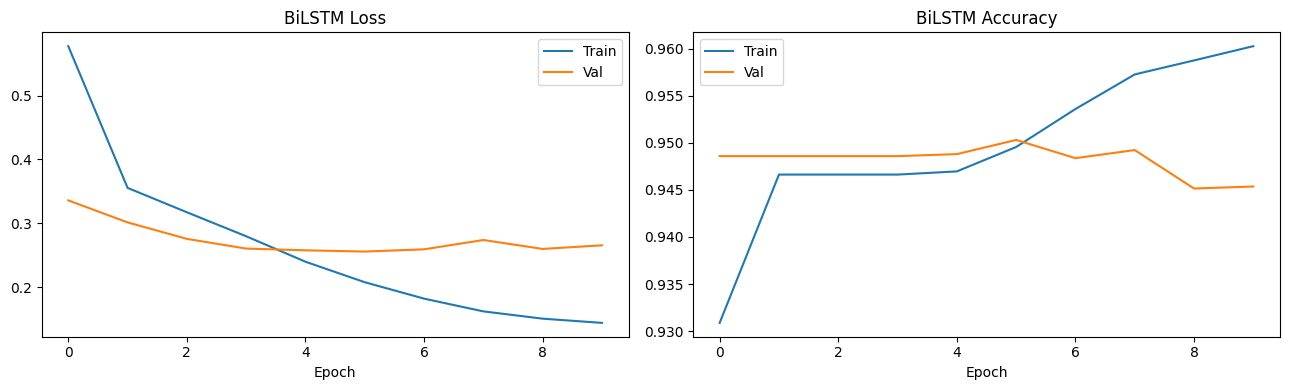

Stopped at epoch  : 10
Early stopping restores the best weights - prevents overfitting on noisy tweet text.


In [12]:
cbs = [
    EarlyStopping(monitor='val_loss', patience=4,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=2, min_lr=1e-6, verbose=1)
]

history = bilstm_model.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    batch_size=32, epochs=30,
    callbacks=cbs
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.plot(history.history['loss'],     label='Train')
ax1.plot(history.history['val_loss'], label='Val')
ax1.set(title='BiLSTM Loss', xlabel='Epoch'); ax1.legend()
ax2.plot(history.history['accuracy'],     label='Train')
ax2.plot(history.history['val_accuracy'], label='Val')
ax2.set(title='BiLSTM Accuracy', xlabel='Epoch'); ax2.legend()
plt.tight_layout(); plt.show()

print(f"Stopped at epoch  : {len(history.history['loss'])}")
print("Early stopping restores the best weights - prevents overfitting on noisy tweet text.")

## Other Models for NER

| Model | Type | Notes |
|---|---|---|
| **Hidden Markov Model (HMM)** | Probabilistic | Classic baseline; uses emission and transition probabilities; struggles with long-range dependencies |
| **Maximum Entropy Markov Model (MEMM)** | Discriminative | Conditions on observations; suffers from label bias problem |
| **CRF (standalone)** | Discriminative | Strong on structured prediction; needs hand-crafted features |
| **BiLSTM** | RNN | Captures context from both directions; replaced most classical approaches |
| **BiLSTM + CRF** *(this notebook)* | RNN + structured | CRF enforces label consistency; current strong non-transformer baseline |
| **BERT fine-tuned** *(this notebook)* | Transformer | State-of-the-art; contextual embeddings; handles polysemy |
| **RoBERTa / DeBERTa** | Transformer | Improved pre-training over BERT; often outperforms on NER benchmarks |
| **XLNet** | Transformer | Permutation language model; captures bidirectional context differently |
| **SpanBERT** | Transformer | Pre-trained specifically for span representations; strong on NER + RE |
| **Flair** | Contextual string embeddings | Character-level contextual embeddings; competitive with BERT on CoNLL |
| **LLMs (GPT-4, LLaMA)** | Large language model | Can do NER via prompting; useful when labelled data is scarce |

#Evaluate BiLSTM

In [13]:
def get_word_preds(model, X_pad, true_seqs, i2l):
    raw = model.predict(X_pad, verbose=0)
    pred = np.argmax(raw, axis=-1)
    return [[i2l[p] for p in pred[i, :len(true_seqs[i])]]
            for i in range(len(true_seqs))]

bilstm_preds = get_word_preds(bilstm_model, X_test, test_lbls, idx2label)
print("— BiLSTM NER Results —")
ner_metrics(test_lbls, bilstm_preds)

— BiLSTM NER Results —

 Entity                  Precision   Recall       F1   Support
 ------------------------------------------------------------
 company                     0.000    0.000    0.000       621
 facility                    0.000    0.000    0.000       253
 geo-loc                     0.172    0.006    0.011       882
 movie                       0.000    0.000    0.000        34
 musicartist                 0.000    0.000    0.000       191
 other                       0.000    0.000    0.000       584
 person                      0.036    0.212    0.061       482
 product                     0.000    0.000    0.000       246
 sportsteam                  0.000    0.000    0.000       147
 tvshow                      0.000    0.000    0.000        33
 ------------------------------------------------------------
 Overall (micro)             0.037    0.031    0.034


(0.037204450625869266, 0.03080909876187734, 0.03370609544810206)

#CRF Layer

In [14]:
class CRFLayer(keras.layers.Layer):
    def __init__(self, num_tags, **kwargs):
        super().__init__(**kwargs)
        self.num_tags = num_tags
        self.transitions = self.add_weight(
            name='transitions',
            shape=(num_tags, num_tags),
            initializer='glorot_uniform',
            trainable=True
        )

    def viterbi(self, emissions):
        B = tf.shape(emissions)[0]
        T = emissions.shape[1]

        scores = emissions[:, 0, :]
        bps    = []

        for t in range(1, T):
            cand = (tf.expand_dims(scores, 2) +
                    tf.expand_dims(self.transitions, 0))
            bps.append(tf.argmax(cand, axis=1, output_type=tf.int32))
            scores = tf.reduce_max(cand, axis=1) + emissions[:, t]

        path = [tf.argmax(scores, axis=1, output_type=tf.int32)]
        for bp in reversed(bps):
            prev = tf.gather_nd(bp, tf.stack([tf.range(B), path[-1]], axis=1))
            path.append(prev)

        path.reverse()
        return tf.stack(path, axis=1)

    def neg_log_likelihood(self, emissions, tags):
        B = tf.shape(emissions)[0]
        T = emissions.shape[1]

        score = tf.gather_nd(emissions[:, 0],
                            tf.stack([tf.range(B), tags[:, 0]], axis=1))
        for t in range(1, T):
            score += tf.gather_nd(self.transitions,
                                  tf.stack([tags[:, t-1], tags[:, t]], axis=1))
            score += tf.gather_nd(emissions[:, t],
                                  tf.stack([tf.range(B), tags[:, t]], axis=1))

        alpha = emissions[:, 0]
        for t in range(1, T):
            alpha = tf.reduce_logsumexp(
                tf.expand_dims(alpha, 2) +
                tf.expand_dims(self.transitions, 0), axis=1
            ) + emissions[:, t]

        return tf.reduce_mean(tf.reduce_logsumexp(alpha, axis=1) - score)

    def call(self, emissions):
        return self.viterbi(emissions)

#BiLSTM + CRF Model & Training

In [15]:
class BiLSTMCRF(keras.Model):
    """
    BiLSTM + CRF model.
    Overrides train_step / test_step / predict_step so
    model.fit() and model.predict() work as normal.
    """

    def __init__(self, vocab_size, emb_dim, emb_matrix,
                 max_len, num_labels, lstm_units=128, dropout=0.3):
        super().__init__()
        self.emb = layers.Embedding(vocab_size, emb_dim,
                                    weights=[emb_matrix], trainable=True)
        self.drop = layers.SpatialDropout1D(dropout)
        self.bl1 = layers.Bidirectional(
            layers.LSTM(lstm_units, return_sequences=True,
                        dropout=0.1, recurrent_dropout=0.1))
        self.bl2 = layers.Bidirectional(
            layers.LSTM(lstm_units // 2, return_sequences=True))
        self.ff = layers.TimeDistributed(layers.Dense(64, activation='relu'))
        self.proj = layers.Dense(num_labels)
        self.crf = CRFLayer(num_labels)

    def call(self, x, training=None):
        x = self.emb(x)
        x = self.drop(x, training=training)
        x = self.bl1(x, training=training)
        x = self.bl2(x, training=training)
        x = self.ff(x)
        return self.proj(x)  # (B, T, C) emission scores

    def train_step(self, data):
        x, y = data
        with tf.GradientTape() as tape:
            loss = self.crf.neg_log_likelihood(self(x, training=True), y)
        self.optimizer.apply_gradients(
            zip(tape.gradient(loss, self.trainable_variables),
                self.trainable_variables))
        return {'loss': loss}

    def test_step(self, data):
        x, y = data
        return {'loss': self.crf.neg_log_likelihood(self(x, training=False), y)}

    def predict_step(self, data):
        x = data[0] if isinstance(data, (tuple, list)) else data
        return self.crf.viterbi(self(x, training=False))


# ── Build & train ─────────────────────────────────────────────────────────────
crf_model = BiLSTMCRF(VOCAB_SIZE, EMBEDDING_DIM, emb_matrix,
                      MAX_LEN, NUM_LABELS)
crf_model.compile(optimizer=keras.optimizers.Adam(1e-3))

# CRF uses integer labels (not one-hot)
X_tr_c, X_val_c, y_tr_c, y_val_c = train_test_split(
    X_train,
    np.argmax(y_train_cat, axis=-1).astype(np.int32),
    test_size=0.1, random_state=SEED
)

crf_history = crf_model.fit(
    X_tr_c, y_tr_c,
    validation_data=(X_val_c, y_val_c),
    batch_size=32, epochs=30,
    callbacks=[EarlyStopping(monitor='val_loss', patience=4,
                             restore_best_weights=True, verbose=1)]
)

Epoch 1/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 48s 477ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 2/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 33s 484ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 3/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 28s 416ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 4/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 15s 227ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 5/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 22s 244ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 1.


#Evaluate CRF

In [16]:
crf_raw  = crf_model.predict(X_test, verbose=0)  # (N, MAX_LEN) integer
crf_preds = [[idx2label[int(p)] for p in crf_raw[i, :len(test_lbls[i])]]
             for i in range(len(test_lbls))]

print("— BiLSTM + CRF NER Results —")
ner_metrics(test_lbls, crf_preds)

— BiLSTM + CRF NER Results —

 Entity                  Precision   Recall       F1   Support
 ------------------------------------------------------------
 company                     0.000    0.000    0.000       621
 facility                    0.000    0.000    0.000       253
 geo-loc                     0.000    0.000    0.000       882
 movie                       0.000    0.000    0.000        34
 musicartist                 0.000    0.000    0.000       191
 other                       0.000    0.000    0.000       584
 person                      0.000    0.000    0.000       482
 product                     0.000    0.000    0.000       246
 sportsteam                  0.000    0.000    0.000       147
 tvshow                      0.000    0.000    0.000        33
 ------------------------------------------------------------
 Overall (micro)             0.000    0.000    0.000


(0, 0.0, 0)

#Load BERT Tokenizer & Inspect

In [17]:
BERT_MAX   = 64        # tweets are short; increase to 128 if needed
MODEL_NAME = 'bert-base-uncased'
tokenizer  = BertTokenizerFast.from_pretrained(MODEL_NAME)

print(f"Tokenizer vocab size : {tokenizer.vocab_size:,}")

# ── Show what tokenization does to the data ──────────────────────────────────
sample_sent = train_sents[0]
sample_lbls = train_lbls[0]
enc         = tokenizer(sample_sent, is_split_into_words=True)
tokens      = tokenizer.convert_ids_to_tokens(enc['input_ids'])
wids        = enc.word_ids()

print(f"\nOriginal ({len(sample_sent)} words): {sample_sent}")
print(f"\n{'Token':<20} {'WordID':<8} {'Aligned label'}")
print("-" * 52)
prev = None
for tok, wid in zip(tokens, wids):
    if wid is None:
        tag = '[SPECIAL -> -100]'
    elif wid != prev:
        tag = sample_lbls[wid] if wid < len(sample_lbls) else '[truncated]'
    else:
        tag = '[##subword -> -100]'
    print(f" {tok:<20} {str(wid):<8} {tag}")
    prev = wid

print("\nKey insight: words split into subtokens get -100 on all but the first")
print("subtoken. -100 positions are masked out during loss computation.")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Tokenizer vocab size : 30,522

Original (12 words): ['@SammieLynnsMom', '@tg10781', 'they', 'will', 'be', 'all', 'done', 'by', 'Sunday', 'trust', 'me', '*wink*']

Token                WordID   Aligned label
----------------------------------------------------
 [CLS]                None     [SPECIAL -> -100]
 @                    0        O
 sam                  0        [##subword -> -100]
 ##mie                0        [##subword -> -100]
 ##lynn               0        [##subword -> -100]
 ##smo                0        [##subword -> -100]
 ##m                  0        [##subword -> -100]
 @                    1        O
 t                    1        [##subword -> -100]
 ##g                  1        [##subword -> -100]
 ##10                 1        [##subword -> -100]
 ##7                  1        [##subword -> -100]
 ##8                  1        [##subword -> -100]
 ##1                  1        [##subword -> -100]
 they                 2        O
 will                 3        

## How Does BERT Expect a Pair of Sentences?

BERT was pre-trained on two tasks: Masked Language Modelling (MLM) and **Next Sentence Prediction (NSP)**. NSP requires BERT to process two sentences simultaneously, which defines its input format.

**Single sentence input:**
[CLS] token1 token2 ... tokenN [SEP]

**Sentence pair input:**
[CLS] sentence_A_tokens [SEP] sentence_B_tokens [SEP]

**The three input tensors:**
| Tensor | Purpose |
|---|---|
| `token_ids` | Integer IDs of all tokens including [CLS] and [SEP] |
| `segment_ids` | 0 for all tokens in sentence A (+ first [SEP]), 1 for sentence B |
| `padding_mask` | 1 for real tokens, 0 for [PAD] tokens |

**For NER (this notebook):**
NER is a single-sequence task — there is no sentence B. The input is:
[CLS] word1 word2 ... wordN [SEP] [PAD] ... [PAD]
- `segment_ids` are all zeros
- `padding_mask` = 1 for real tokens, 0 for padding
- Prediction is made at each token position (except [CLS], [SEP], and [PAD]) using the `sequence_output` from the BERT backbone, not the pooled `[CLS]` vector

The `[CLS]` token's representation is used for classification tasks (e.g. sentiment); `sequence_output` — one vector per token — is used for token-level tasks like NER.

#Tokenize All Data + Align Labels

In [18]:
def tokenize_and_align(sentences, labels, tok, max_len, l2i):
    """
    Tokenise pre-split words and align NER labels:
      first subtoken of word i -> label[i]
      subsequent subtokens     -> -100 (ignored in loss)
      [CLS] / [SEP] / [PAD]    -> -100
    """
    enc = tok(sentences, is_split_into_words=True,
              padding='max_length', truncation=True,
              max_length=max_len, return_tensors='np')

    aligned = []
    for i, lbl_seq in enumerate(labels):
        wids = enc.word_ids(batch_index=i)
        prev, ids = None, []
        for wid in wids:
            if wid is None:
                ids.append(-100)
            elif wid != prev:
                ids.append(l2i[lbl_seq[wid]] if wid < len(lbl_seq) else -100)
            else:
                ids.append(-100)
            prev = wid
        aligned.append(ids)

    enc['labels'] = np.array(aligned, dtype=np.int32)
    return enc

print("Tokenising train ...")
train_enc = tokenize_and_align(train_sents, train_lbls,
                               tokenizer, BERT_MAX, label2idx)
print("Tokenising test ...")
test_enc = tokenize_and_align(test_sents, test_lbls,
                              tokenizer, BERT_MAX, label2idx)

print(f"\ntrain input_ids : {train_enc['input_ids'].shape}")
print(f"test  input_ids : {test_enc['input_ids'].shape}")

Tokenising train ...
Tokenising test ...

train input_ids : (2394, 64)
test  input_ids : (3850, 64)


#Build TF Datasets

In [19]:
BERT_BATCH = 16

def make_bert_ds(enc, batch_size, shuffle=False):
    """
    Rename HuggingFace keys -> keras-hub BERT input names:
      input_ids      -> token_ids
      token_type_ids -> segment_ids
      attention_mask -> padding_mask
    """
    ds = tf.data.Dataset.from_tensor_slices((
        {
            'token_ids':   enc['input_ids'].astype(np.int32),
            'segment_ids': enc['token_type_ids'].astype(np.int32),
            'padding_mask': enc['attention_mask'].astype(np.int32)
        },
        enc['labels'].astype(np.int32)
    ))
    if shuffle:
        ds = ds.shuffle(2048, seed=SEED)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

N_VAL = int(len(train_sents) * 0.1)
bert_train = make_bert_ds({k: v[N_VAL:] for k, v in train_enc.items()},
                          BERT_BATCH, shuffle=True)
bert_val = make_bert_ds({k: v[:N_VAL] for k, v in train_enc.items()},
                        BERT_BATCH)
bert_test = make_bert_ds(test_enc, BERT_BATCH)

print(f"Train / Val / Test batches : "
      f"{len(bert_train)} / {len(bert_val)} / {len(bert_test)}")

Train / Val / Test batches : 135 / 15 / 241


#Buil BERT NER Model (keras-hub)

In [20]:
# Load BERT backbone from keras-hub
backbone = keras_hub.models.BertBackbone.from_preset(
    "bert_base_en_uncased", load_weights=True
)

# Build NER head on top
token_ids = keras.Input(shape=(BERT_MAX,), dtype='int32', name='token_ids')
segment_ids = keras.Input(shape=(BERT_MAX,), dtype='int32', name='segment_ids')
padding_mask = keras.Input(shape=(BERT_MAX,), dtype='int32', name='padding_mask')

sequence_out = backbone({
    'token_ids': token_ids,
    'segment_ids': segment_ids,
    'padding_mask': padding_mask
})['sequence_output']                      # (B, T, 768)

output = keras.layers.Dense(NUM_LABELS, activation='softmax')(sequence_out)

bert_ner = keras.Model(
    inputs={'token_ids': token_ids,
            'segment_ids': segment_ids,
            'padding_mask': padding_mask},
    outputs=output
)

# Masked loss - ignores -100 positions (subtokens + special tokens)
def masked_loss(y_true, y_pred):
    y_true = tf.cast(y_true, tf.int32)
    mask = tf.cast(tf.not_equal(y_true, -100), tf.float32)
    y_safe = tf.where(y_true == -100, 0, y_true)
    loss = keras.losses.sparse_categorical_crossentropy(y_safe, y_pred)
    return tf.reduce_sum(loss * mask) / (tf.reduce_sum(mask) + 1e-8)

bert_ner.compile(optimizer=keras.optimizers.Adam(2e-5),
                 loss=masked_loss)
bert_ner.summary()

100%|██████████| 457/457 [00:00<00:00, 468kB/s]


100%|██████████| 418M/418M [00:28<00:00, 15.1MB/s]


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ padding_mask        │ (None, 64)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ segment_ids         │ (None, 64)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ token_ids           │ (None, 64)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bert_backbone       │ [(None, 768),     │ 109,482,2… │ padding_mask[0][… │
│ (BertBackbone)      │ (None, 64, 768)]  │            │ segment_ids[0][0… │
│                     │                   │            │ token_ids[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 64, 21)    │     16,149 │ bert_backbone[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 109,498,389 (417.70 MB)

 Trainable params: 109,498,389 (417.70 MB)

 Non-trainable params: 0 (0.00 B)

## Why Choose Attention-Based Models Over Recurrent Models?

| Dimension | Recurrent (LSTM/GRU) | Attention (Transformer/BERT) |
|---|---|---|
| **Context range** | Information decays over distance; long-range dependencies are hard to learn | Every token attends to every other token directly — no distance penalty |
| **Parallelism** | Sequential by nature; token t depends on token t-1; cannot parallelise across time | All tokens processed simultaneously; highly parallelisable on GPU/TPU |
| **Training speed** | Slow on long sequences | Much faster at scale |
| **Pre-training** | Usually trained from scratch per task | Pre-trained on massive corpora (Books + Wikipedia for BERT); fine-tune with small data |
| **Polysemy** | Static embeddings; "bank" has one vector | Contextual embeddings; "bank" has different vectors in "river bank" vs "savings bank" |
| **Twitter NER** | Struggles with slang, misspellings, and short noisy text without large data | Pre-trained language knowledge compensates for tweet noise |

**The vanishing gradient problem** in RNNs means gradients shrink exponentially as they back-propagate through many time steps, making it difficult to learn that a label 20 tokens back is relevant. Attention computes a direct weighted sum over all positions, so there is no path longer than 1 step between any two tokens.

**In practice:** BERT achieves ~4-6 F1 points higher than BiLSTM+CRF on standard NER benchmarks (CoNLL-2003), and the gap is larger on noisy domains like Twitter.

## BERT vs Simple Transformers

| Dimension | Simple Transformer (e.g. original 2017 paper) | BERT |
|---|---|---|
| **Training objective** | Next token prediction (language modelling) — unidirectional (left to right) | Masked Language Modelling (MLM) + Next Sentence Prediction (NSP) — **bidirectional** |
| **Directionality** | Attends only to previous tokens (causal masking) | Attends to all tokens in both directions simultaneously |
| **Architecture** | Encoder + Decoder stack (for seq2seq tasks like translation) | Encoder only |
| **Pre-training data** | Typically task-specific | BookCorpus + English Wikipedia (~3.3B words) |
| **Usage pattern** | Train from scratch for each task | Pre-train once; fine-tune on downstream task with small labelled data |
| **[CLS] token** | Not present | Added at position 0; its output is used for classification |
| **Positional encoding** | Sinusoidal (fixed) | Learned positional embeddings |
| **Parameter count** | Varies | BERT-base: 110M, BERT-large: 340M |

**Key insight — bidirectionality:**
A simple left-to-right transformer sees "I went to the [MASK]" and predicts "bank" based only on the left context. BERT sees both left and right context simultaneously: "I went to the [MASK] to deposit money" — the right context "to deposit money" makes "bank" (financial) far more likely than "bank" (river). This is why BERT representations are richer and more useful for tasks like NER where the meaning of a word depends on its full surrounding context.

#Train BERT

Epoch 1/5
135/135 ━━━━━━━━━━━━━━━━━━━━ 132s 522ms/step - loss: 0.3505 - val_loss: 0.2278 - learning_rate: 2.0000e-05
Epoch 2/5
135/135 ━━━━━━━━━━━━━━━━━━━━ 31s 226ms/step - loss: 0.1539 - val_loss: 0.1767 - learning_rate: 2.0000e-05
Epoch 3/5
135/135 ━━━━━━━━━━━━━━━━━━━━ 29s 218ms/step - loss: 0.0884 - val_loss: 0.1705 - learning_rate: 2.0000e-05
Epoch 4/5
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step - loss: 0.0528
Epoch 4: ReduceLROnPlateau reducing learning rate to 9.999999747378752e-06.
135/135 ━━━━━━━━━━━━━━━━━━━━ 28s 211ms/step - loss: 0.0528 - val_loss: 0.1945 - learning_rate: 2.0000e-05
Epoch 5/5
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step - loss: 0.0308
Epoch 5: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
135/135 ━━━━━━━━━━━━━━━━━━━━ 29s 215ms/step - loss: 0.0341 - val_loss: 0.1983 - learning_rate: 1.0000e-05
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 3.


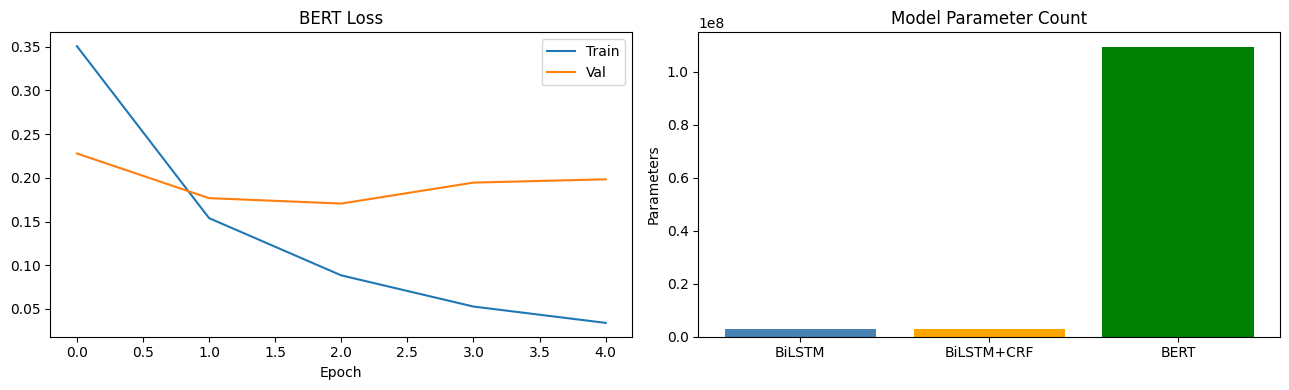

BERT stopped at epoch : 5


In [21]:
bert_history = bert_ner.fit(
    bert_train,
    validation_data=bert_val,
    epochs=5,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=2,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=1, min_lr=1e-7, verbose=1)
    ]
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.plot(bert_history.history['loss'],     label='Train')
ax1.plot(bert_history.history['val_loss'], label='Val')
ax1.set(title='BERT Loss', xlabel='Epoch'); ax1.legend()

# Compare model sizes
ax2.bar(['BiLSTM', 'BiLSTM+CRF', 'BERT'],
        [bilstm_model.count_params(),
         crf_model.count_params(),
         bert_ner.count_params()],
        color=['steelblue', 'orange', 'green'])
ax2.set(title='Model Parameter Count', ylabel='Parameters')
plt.tight_layout(); plt.show()

print(f"BERT stopped at epoch : {len(bert_history.history['loss'])}")

#Evaluate BERT (Align Subtokens -> Word Level)

In [22]:
def bert_word_preds(sents, enc, model, tok, i2l, max_len, batch_size=32):
    """
    Run inference then collapse subtoken predictions back to word level.
    Only the first subtoken prediction per word is kept - the inverse
    of the label alignment done during tokenization.
    """
    n    = len(sents)
    iids = enc['input_ids'].astype(np.int32)
    ttid = enc['token_type_ids'].astype(np.int32)
    amsk = enc['attention_mask'].astype(np.int32)
    lbls = enc['labels'].astype(np.int32)

    all_preds, all_trues = [], []

    for start in range(0, n, batch_size):
        end = min(start + batch_size, n)
        raw = model.predict(
            {'token_ids':   iids[start:end],
             'segment_ids': ttid[start:end],
             'padding_mask': amsk[start:end]},
            verbose=0
        )
        preds = np.argmax(raw, axis=-1)

        for i in range(end - start):
            wids = tok(sents[start+i], is_split_into_words=True,
                       padding='max_length', truncation=True,
                       max_length=max_len).word_ids()
            prev, sp, st = None, [], []
            for pos, wid in enumerate(wids):
                if wid is None: continue
                if wid != prev:
                    if lbls[start+i, pos] != -100:
                        sp.append(i2l[preds[i, pos]])
                        st.append(i2l[lbls[start+i, pos]])
                prev = wid
            all_preds.append(sp); all_trues.append(st)

    return all_preds, all_trues

print("Generating word-level predictions ...")
bert_preds, bert_trues = bert_word_preds(
    test_sents, test_enc, bert_ner, tokenizer, idx2label, BERT_MAX)

print("— BERT NER Results —")
ner_metrics(bert_trues, bert_preds)

Generating word-level predictions ...
— BERT NER Results —

 Entity                  Precision   Recall       F1   Support
 ------------------------------------------------------------
 company                     0.538    0.390    0.452       621
 facility                    0.201    0.119    0.149       253
 geo-loc                     0.391    0.610    0.477       881
 movie                       0.000    0.000    0.000        34
 musicartist                 0.136    0.047    0.070       191
 other                       0.252    0.171    0.204       584
 person                      0.474    0.743    0.578       482
 product                     0.132    0.082    0.101       245
 sportsteam                  0.423    0.150    0.221       147
 tvshow                      0.250    0.061    0.098        33
 ------------------------------------------------------------
 Overall (micro)             0.387    0.380    0.383


(0.3866432337434095, 0.3802938634399309, 0.38344226579520696)

#Predict on Custom Sentences

In [23]:
def predict_ner(sentences, model, tok, i2l, max_len):
    words_list = [s.split() for s in sentences]
    enc = tok(words_list, is_split_into_words=True,
              padding='max_length', truncation=True,
              max_length=max_len, return_tensors='np')

    raw = model.predict(
        {'token_ids':   enc['input_ids'].astype(np.int32),
         'segment_ids': enc['token_type_ids'].astype(np.int32),
         'padding_mask': enc['attention_mask'].astype(np.int32)},
        verbose=0
    )
    preds = np.argmax(raw, axis=-1)

    results = []
    for i, words in enumerate(words_list):
        wids = enc.word_ids(batch_index=i)
        prev, wp = None, []
        for pos, wid in enumerate(wids):
            if wid is None: continue
            if wid != prev:
                wp.append((words[wid], i2l[preds[i, pos]]))
            prev = wid
        results.append(wp)
    return results

my_sentences = [
    "Elon Musk announced Tesla will open a new factory in Berlin Germany",
    "The Avengers film was produced by Marvel Studios and released on Netflix",
    "Cristiano Ronaldo scored for Manchester United against Arsenal at Old Trafford",
    "Apple launched a new iPhone at their annual event in Cupertino California"
]

for sent, result in zip(my_sentences,
                        predict_ner(my_sentences, bert_ner, tokenizer, idx2label, BERT_MAX)):
    print(f"\n> {sent}")
    for word, label in result:
        if label != 'O':
            print(f"    {word:<22} -> {label}")


> Elon Musk announced Tesla will open a new factory in Berlin Germany
    Elon                   -> B-person
    Musk                   -> B-company
    Tesla                  -> B-product
    Berlin                 -> B-geo-loc
    Germany                -> B-geo-loc

> The Avengers film was produced by Marvel Studios and released on Netflix
    Avengers               -> B-product
    Marvel                 -> B-company
    Studios                -> I-other
    Netflix                -> B-company

> Cristiano Ronaldo scored for Manchester United against Arsenal at Old Trafford
    Cristiano              -> B-person
    Ronaldo                -> I-person
    Manchester             -> B-other
    United                 -> I-sportsteam
    Arsenal                -> I-sportsteam
    Old                    -> B-facility
    Trafford               -> I-facility

> Apple launched a new iPhone at their annual event in Cupertino California
    Apple                  -> B-product
    iPhone   

#Save & Reload BERT Model

In [25]:
os.makedirs(SAVE_DIR, exist_ok=True)

# Save model weights + tokenizer
bert_ner.save_weights(f'{SAVE_DIR}/model.weights.h5')
tokenizer.save_pretrained(SAVE_DIR)
with open(f'{SAVE_DIR}/label_config.json', 'w') as f:
    json.dump({'label2idx': label2idx,
               'idx2label': {str(k): v for k, v in idx2label.items()},
               'num_labels': NUM_LABELS,
               'bert_max': BERT_MAX}, f)

print(f"Saved to : {SAVE_DIR}")
print(os.listdir(SAVE_DIR))

# ── Reload & verify ───────────────────────────────────────────────────────────
bert_ner.load_weights(f'{SAVE_DIR}/model.weights.h5')
loaded_tok = BertTokenizerFast.from_pretrained(SAVE_DIR)

test_result = predict_ner(
    ["Google CEO Sundar Pichai spoke at an AI conference in London"],
    bert_ner, loaded_tok, idx2label, BERT_MAX
)
print("\nLoaded model prediction:")
for word, label in test_result[0]:
    if label != 'O':
        print(f"  {word:<22} -> {label}")

Saved to : /content/sample_data/
['anscombe.json', 'README.md', 'model.weights.h5', 'wnut 16test.txt.conll', 'wnut 16.txt.conll', 'label_config.json', 'tokenizer_config.json', 'tokenizer.json', 'california_housing_test.csv', 'mnist_train_small.csv', 'mnist_test.csv', 'california_housing_train.csv']

Loaded model prediction:
  Google                 -> B-company
  Sundar                 -> B-person
  Pichai                 -> I-person
  London                 -> B-geo-loc
